In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("air_fryers_clean_brand_year.csv")

#1.1

brands = sorted(df["brand"].unique())
palette = dict(zip(brands, sns.color_palette("tab10", n_colors=len(brands))))

print(f"Brands ({df['brand'].nunique()}):", brands)
print(f"Years ({df['year'].nunique()}):", sorted(df["year"].unique()))
print(f"Rows: {len(df)}")
print(f"\nMissing values:\n{df.isnull().sum()}")

Brands (10): ['chefman', 'cosori', 'cuisinart', 'dash', 'gowise usa', 'instant_pot', 'ninja', 'nuwave', 'oster', 'ultrean']
Years (5): [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]
Rows: 50

Missing values:
category             0
year                 0
brand                0
purchase_count       0
product_count        0
avg_price            0
avg_rating           0
compact_share        0
dual_basket_share    0
oven_style_share     0
rotisserie_share     0
window_share         0
market_purchases     0
brand_share          0
log_brand_share      0
dtype: int64


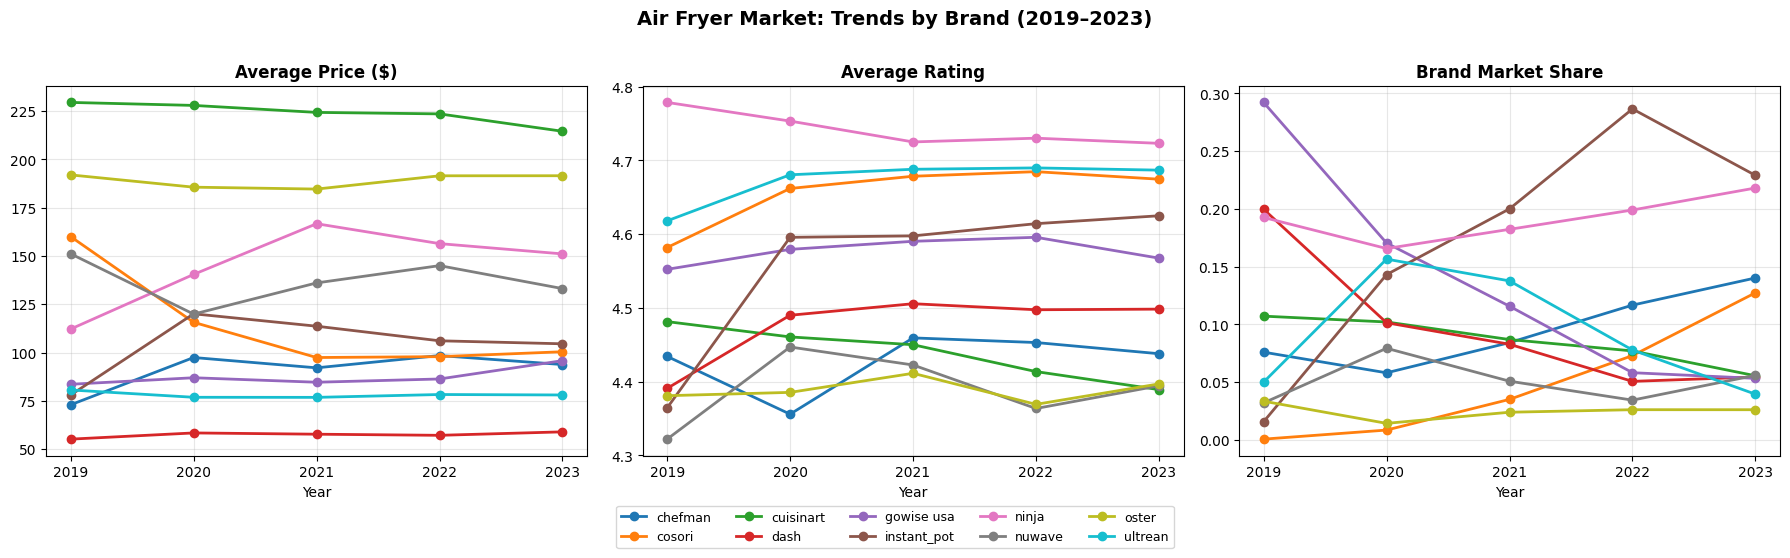

In [2]:
#1.2
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Air Fryer Market: Trends by Brand (2019–2023)", fontsize=14, fontweight="bold", y=1.01)

metrics = [
    ("avg_price",   "Average Price ($)",  axes[0]),
    ("avg_rating",  "Average Rating",     axes[1]),
    ("brand_share", "Brand Market Share", axes[2]),
]

for col, title, ax in metrics:
    for brand in brands:
        grp = df[df["brand"] == brand]
        ax.plot(grp["year"], grp[col], marker="o", label=brand, color=palette[brand], linewidth=2)
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Year")
    ax.set_xticks([2019, 2020, 2021, 2022, 2023])
    ax.grid(alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=5, fontsize=9,
           bbox_to_anchor=(0.5, -0.08), frameon=True)
plt.tight_layout()
plt.show()

In [4]:
#1.3
char_cols = ["compact_share", "dual_basket_share", "oven_style_share",
             "rotisserie_share", "window_share"]
char_labels = ["Compact", "Dual Basket", "Oven Style", "Rotisserie", "Window"]

print("=== Feature Prevalence (mean share across all brand-years) ===")
for label, col in zip(char_labels, char_cols):
    val = df[col].mean()
    print(f"  {label:15s}: {val:.3f}")

=== Feature Prevalence (mean share across all brand-years) ===
  Compact        : 0.980
  Dual Basket    : 0.002
  Oven Style     : 0.563
  Rotisserie     : 0.071
  Window         : 0.037


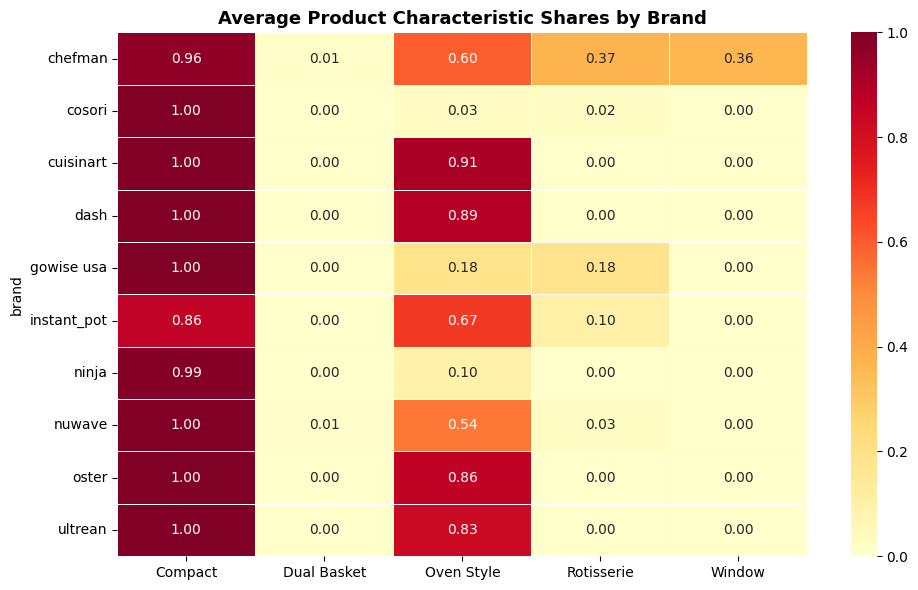

In [5]:
#1.3

brand_chars = df.groupby("brand")[char_cols].mean()
brand_chars.columns = char_labels

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(brand_chars, annot=True, fmt=".2f", cmap="YlOrRd",
            linewidths=0.5, ax=ax, vmin=0, vmax=1)
ax.set_title("Average Product Characteristic Shares by Brand", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [6]:
#1.3
print("=== Average Price by Brand ===")
print(df.groupby("brand")["avg_price"].mean().sort_values(ascending=False).round(2))

print("\n=== Average Market Share by Brand ===")
print(df.groupby("brand")["brand_share"].mean().sort_values(ascending=False).round(4))

print("\n=== Average Rating by Brand ===")
print(df.groupby("brand")["avg_rating"].mean().sort_values(ascending=False).round(3))

print("\n=== Market Share Change: 2019 vs 2023 ===")
pivot = df.pivot(index="brand", columns="year", values="brand_share")[[2019, 2023]]
pivot["change"] = pivot[2023] - pivot[2019]
print(pivot.round(4).sort_values("change"))

=== Average Price by Brand ===
brand
cuisinart      223.95
oster          189.03
ninja          145.34
nuwave         137.02
cosori         114.27
instant_pot    104.46
chefman         90.94
gowise usa      87.45
ultrean         78.11
dash            57.48
Name: avg_price, dtype: float64

=== Average Market Share by Brand ===
brand
ninja          0.1916
instant_pot    0.1749
gowise usa     0.1380
dash           0.0979
chefman        0.0951
ultrean        0.0924
cuisinart      0.0858
nuwave         0.0506
cosori         0.0490
oster          0.0249
Name: brand_share, dtype: float64

=== Average Rating by Brand ===
brand
ninja          4.742
ultrean        4.673
cosori         4.656
gowise usa     4.577
instant_pot    4.559
dash           4.476
cuisinart      4.439
chefman        4.428
nuwave         4.390
oster          4.389
Name: avg_rating, dtype: float64

=== Market Share Change: 2019 vs 2023 ===
year           2019    2023  change
brand                              
gowise usa   0.

### Product Characteristics: Findings

**Common features:**
- **Compact** (mean share ≈ 0.98): Nearly universal — almost every product across all brands is compact.
- **Oven style** (mean share ≈ 0.56): Present in roughly half of all brand-year offerings, making it the second most common configuration.

**Rare features:**
- **Rotisserie** (mean share ≈ 0.07): A niche add-on offered by only a handful of brands.
- **Window** (mean share ≈ 0.04): Very rare, appearing mainly in Chefman's lineup in later years.
- **Dual basket** (mean share ≈ 0.002): Extremely rare, only beginning to appear in 2022–2023.

**Brand specialization:**
- **Cuisinart** and **Oster** specialize in oven-style products (~0.89–0.93 oven share).
- **GoWise USA** is the standout rotisserie brand (~0.18 rotisserie share).
- **Ninja** and **Cosori** are almost exclusively compact with near-zero oven presence.
- **Chefman** is the only brand with a meaningful window share, growing in 2022–2023.

## Market Summary

The air fryer market from 2019–2023 is competitive and shifting. Ninja and Instant Pot are the dominant brands by 2023, together accounting for nearly half of all purchases, up dramatically from 2019 when GoWise USA and Dash led. Cuisinart is the most expensive brand (~$224 avg) while Dash is the cheapest (~$57). Ratings are tight across brands (4.39–4.74 stars), with Ninja topping both ratings and market share. The market is clearly not stable: GoWise USA fell from ~29% share in 2019 to ~5% in 2023, while Cosori grew from near zero to ~13%.